# Predicting Diabetes Progression
## Machine Learning Project — Diabetes Dataset (scikit-learn)

**Objective:** Predict the progression of the disease one year ahead using 10 clinical variables.  
We are collaborating with a healthcare organization focused on the prevention and monitoring of chronic diseases.

---

## 1. Library Imports

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# graphics settings
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100


## 2. Dataset Loading and Inspection

The scikit-learn Diabetes dataset contains **442 samples** and **10** already standardized (mean 0, variance 1) numerical **features**:
`age`, `sex`, `bmi`, `bp`, `s1`–`s6` (blood serum indicators).  
The **target** is a quantitative measure of disease progression at 1 year.


In [2]:
diabetes = load_diabetes()
df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
df['target'] = diabetes.target

print("Dataset dimension:", df.shape)
print("\nMissing values per column:\n", df.isnull().sum())
print("\nDescriptive statistics::")
df.describe().round(3)


Dataset dimension: (442, 11)

Missing values per column:
 age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64

Descriptive statistics::


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,442.000,442.000,442.000,442.000,442.000,442.000,442.000,442.000,442.000,442.000,442.000
mean,-0.000,0.000,-0.000,-0.000,-0.000,0.000,-0.000,-0.000,0.000,0.000,152.133
std,0.048,0.048,0.048,0.048,0.048,0.048,0.048,0.048,0.048,0.048,77.093
min,-0.107,-0.045,-0.090,-0.112,-0.127,-0.116,-0.102,-0.076,-0.126,-0.138,25.000
25%,-0.037,-0.045,-0.034,-0.037,-0.034,-0.030,-0.035,-0.039,-0.033,-0.033,87.000
50%,0.005,-0.045,-0.007,-0.006,-0.004,-0.004,-0.007,-0.003,-0.002,-0.001,140.500
75%,0.038,0.051,0.031,0.036,0.028,0.030,0.029,0.034,0.032,0.028,211.500
max,0.111,0.051,0.171,0.132,0.154,0.199,0.181,0.185,0.134,0.136,346.000


## 3. Exploratory Data Analysis (EDA)

We analyze the distribution of the target and the correlation between features.  
This helps us understand the behavior of the data before training the model.

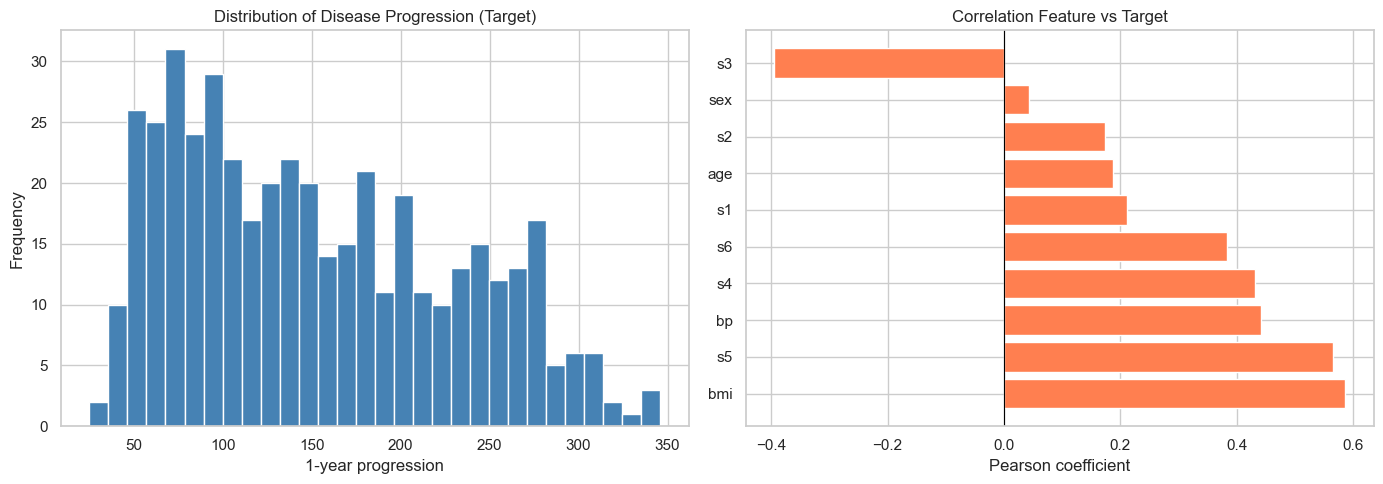

Most correlated features with the target (top 3): ['bmi', 's5', 'bp']


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Target distribution
axes[0].hist(df['target'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Disease Progression (Target)')
axes[0].set_xlabel('1-year progression')
axes[0].set_ylabel('Frequency')

# Target correlation
corr_target = df.corr()['target'].drop('target').sort_values(ascending=False)
axes[1].barh(corr_target.index, corr_target.values, color='coral')
axes[1].set_title('Correlation Feature vs Target')
axes[1].set_xlabel('Pearson coefficient')
axes[1].axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

print("Most correlated features with the target (top 3):", corr_target.head(3).index.tolist())


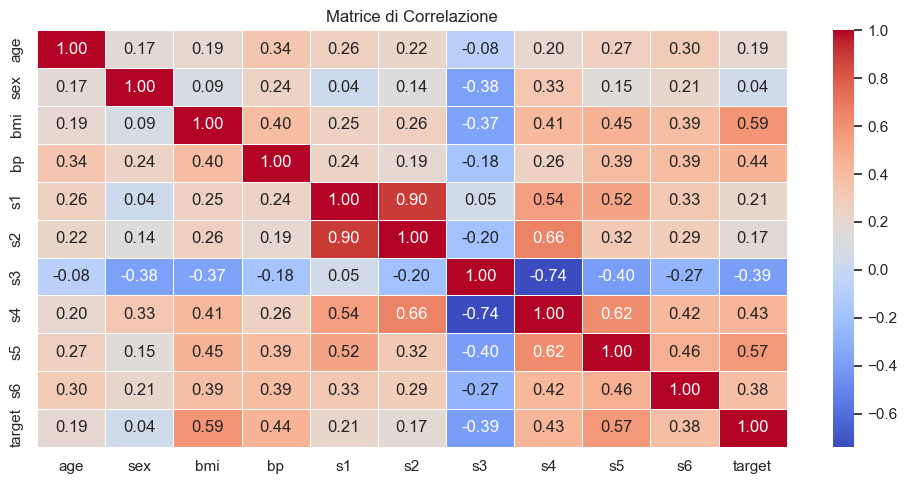

In [4]:
# Heatmap di correlazione completa
plt.figure(figsize=(10, 5))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title('Matrice di Correlazione')
plt.tight_layout()
plt.show()


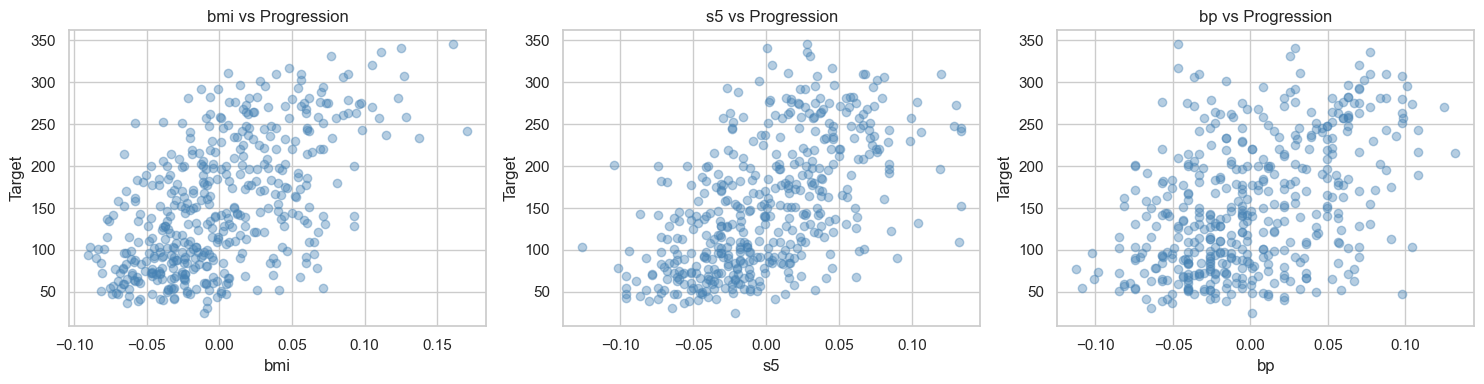

In [5]:
# Scatter Plot of the Most Informative Features
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, feat in zip(axes, ['bmi', 's5', 'bp']):
    ax.scatter(df[feat], df['target'], alpha=0.4, color='steelblue')
    ax.set_xlabel(feat)
    ax.set_ylabel('Target')
    ax.set_title(f'{feat} vs Progression')
plt.tight_layout()
plt.show()


We visualize the relationship between the 3 features most correlated
with the target (bmi, s5, bp) and disease progression.

- bmi (Body Mass Index): higher BMI is associated with greater insulin resistance, so we expect a positive relationship.
- s5 (log-triglycerides): a lipid indicator closely linked to glucose metabolism and diabetes progression.
- bp (blood pressure): elevated values are correlated with cardiovascular complications typical of diabetes.

If points show an upward trend from left to right, the feature has a positive correlation with progression.
Scattered points with no pattern indicate low correlation.

## 3.5 Feature Engineering — Explicit Reasoning on Correlations

The EDA revealed two strong correlations between features:
- **s1 and s2: r ≈ 0.90** (total cholesterol and LDL — nearly redundant)
- **s3 and s4: r ≈ -0.74** (HDL and total/HDL cholesterol ratio — inversely linked)

Before moving to preprocessing, we need to make an explicit decision:
should we remove these correlated features, or keep them all?

---

### Do correlations affect GBR the same way they affect a linear model?

**No — and this distinction matters.**

In a **linear model** (like Ridge Regression), high correlation between features
causes multicollinearity. This makes the coefficients unstable: if s1 and s2
carry almost the same information, the model struggles to decide how much weight
to assign to each. Ridge handles this with L2 regularization, but the problem
is structural.

A **Gradient Boosting Regressor** works differently. It builds a sequence of
decision trees, and each tree selects the single best feature to split on at
each node. If s1 and s2 are correlated, the model will simply learn to rely
more on whichever one is slightly more informative at each step. The redundancy
is tolerated — it does not destabilize the model the way it does in linear
regression.

---

### Decision: keep all features

We decided **not to remove** any feature. Here is why:

1. **Small dataset** — with only 442 samples, removing features means losing
   information we can't afford to discard without a clear benefit.
2. **GBR is robust to redundancy** — the feature importance scores (computed
   after training) will naturally show which of the correlated features
   contributes more, without us having to intervene manually.
3. **Baseline comparison** — keeping all features for both Ridge and GBR
   ensures a fair, apples-to-apples comparison between the two models.


## 4. Data Preparation

We separate features and target, then split the dataset into **training (75%)** and **test (25%)**.  
We use `random_state=42` for reproducibility.  
The features are already standardized in the original dataset, so no further scaling is needed.

In [6]:
X = df.drop(columns='target')
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")


Training set: 331 samples
Test set:     111 samples


## 5. Baseline Model — Ridge Regression

Before training the Gradient Boosting Regressor, we establish a **baseline** using Ridge Regression — a regularized linear model that adds an L2 penalty to the ordinary least squares objective.
- The dataset is already standardized (mean = 0, variance = 1), which is the
   ideal condition for linear models with regularization

- We use `RidgeCV` with 5-fold cross-validation to automatically select the best
regularization strength `alpha` from the candidate set [0.01, 0.1, 1, 10, 100].
A higher alpha means stronger regularization (coefficients shrink toward zero),
which helps prevent overfitting on correlated features such as s1/s2 and s3/s4.

In [7]:
alphas = [0.01, 0.1, 1, 10, 100,]
ridge = RidgeCV(alphas=alphas, cv=5)
ridge.fit(X_train, y_train)

Y_predict_ridge = ridge.predict(X_test)
R2_ridge = r2_score(y_test, Y_predict_ridge)
mae_ridge = mean_absolute_error(y_test, Y_predict_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, Y_predict_ridge))

print(f'alpha selected: {ridge.alpha_:.4f}')
print(f'R2 score : {R2_ridge:.4f}')
print(f'mae score : {mae_ridge:.4f}')
print(f'rmse score : {rmse_ridge:.4f}')

alpha selected: 0.1000
R2 score : 0.4918
mae score : 41.5532
rmse score : 53.0098


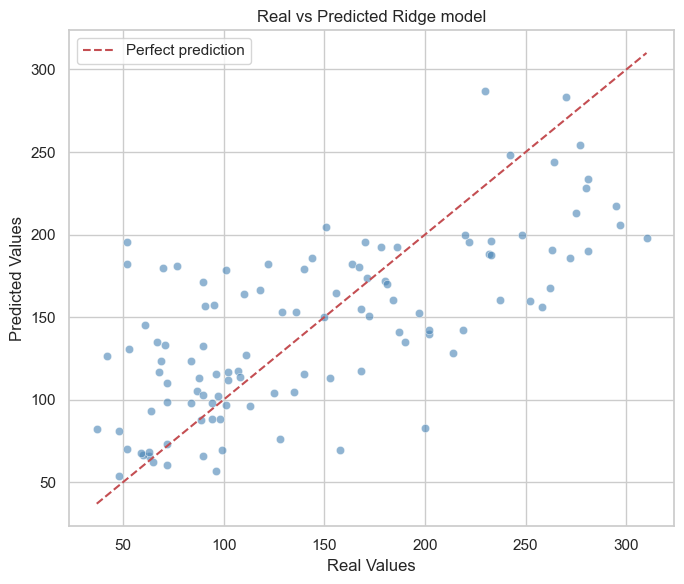

In [8]:
fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(y_test, Y_predict_ridge, alpha=0.6, color='steelblue', edgecolors='white', linewidths=0.5)
lims = [min(y_test.min(), Y_predict_ridge.min()), max(y_test.max(), Y_predict_ridge.max())]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel('Real Values')
ax.set_ylabel('Predicted Values')
ax.set_title('Real vs Predicted Ridge model')
ax.legend()
plt.tight_layout()
plt.show()


### Baseline Results

The cross-validation selected **alpha = 0.10**, which means the model needed
only a small amount of regularization. In practice, this means the features
were already clean and well-scaled enough that Ridge did not need to
aggressively shrink the coefficients.

The model achieved an **R² of 0.49**, meaning it correctly explains about
half of the variation in diabetes progression. Not perfect, but a solid
starting point for a dataset with only 10 features and 442 patients.

The **MAE of 41.55** means that, on average, our predictions are off by
about 41 units. Since the target ranges from 25 to 346, this is roughly
a 13% error — not bad for a simple linear model.

## 6. Model Selection: Gradient Boosting Regressor

We choose **Gradient Boosting Regressor** for several reasons:
- It is an ensemble method based on boosting: it builds trees sequentially, where each tree corrects the errors of the previous one.
- It generally outperforms Random Forest on small datasets like this one.
- It has more significant hyperparameters to optimize: `n_estimators`, `learning_rate`, `max_depth`.

**Main hyperparameter:** `learning_rate` — controls the contribution of each tree. Lower values require more trees but generally produce better generalization.

In [9]:
# Hyperparameter grid to explore
params = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [2, 3, 5],
    'min_samples_split': [2, 5]
}

# GridSearchCV with 5-fold cross-validation
# scoring='neg_mean_squared_error' is the standard scoring for regression
grid_search = GridSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_grid=params,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("\nMiglior combinazione di iperparametri trovata:")
print(grid_search.best_params_)
print(f"\nMiglior MSE: {-grid_search.best_score_:.2f}")


Fitting 5 folds for each of 54 candidates, totalling 270 fits

Miglior combinazione di iperparametri trovata:
{'learning_rate': 0.05, 'max_depth': 2, 'min_samples_split': 5, 'n_estimators': 100}

Miglior MSE: 3345.43


## 7. Evaluation on the Test Set

We evaluate the best model using three metrics:
- **R²**: how much variance of the target is explained (1 = perfect)
- **MAE**: mean absolute error in the original units of the target
- **RMSE**: penalizes large errors more heavily than MAE

In [10]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

r2  = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"  R² Score : {r2:.4f}")
print(f"  MAE      : {mae:.2f}")
print(f"  RMSE     : {rmse:.2f}")

# R² interpretation
if r2 >= 0.5:
    print(f"\nThe model explains {r2*100:.1f}% of the variance in the target variable.")
else:
    print("\nLow R²: the model struggles to generalize on this dataset.")


  R² Score : 0.4748
  MAE      : 42.65
  RMSE     : 53.89

Low R²: the model struggles to generalize on this dataset.


- In fields such as medicine, biology, and psychology, data has extremely high natural variability — every patient is different, and many factors (genetics, lifestyle, therapy adherence) are not present in the dataset. An R² of 0.47 in the medical field is considered an honest and realistic result, well above the threshold of 0.15–0.20 generally considered meaningful in clinical research. Howewer The model is useful for identifying general risk trends (low/medium/high), but not precise enough to support individual clinical decisions without further validation. An R² of 0.47 accurately reflects this visual dispersion. 

## 8. Actual vs Predicted — Residual Analysis

### Graph 1 — Actual vs Predicted: "How accurate are the predictions?"
Each point represents a patient: the X axis shows the **real** progression value,
the Y axis shows what the model **predicted**.
The red dashed diagonal line is the **perfect prediction reference** — the closer
the points are to this line, the more accurate the model is.

### Graph 2 — Residuals: "How does the model make mistakes?"
A residual is the difference between the real and predicted value: `real - predicted`.
The horizontal dashed line at zero is the ideal reference.
-**Healthy model**: points scattered randomly around zero — errors are casual, no systematic pattern.
-**Problematic model**: points follow a curve — the model is systematically
  underestimating or overestimating certain values.


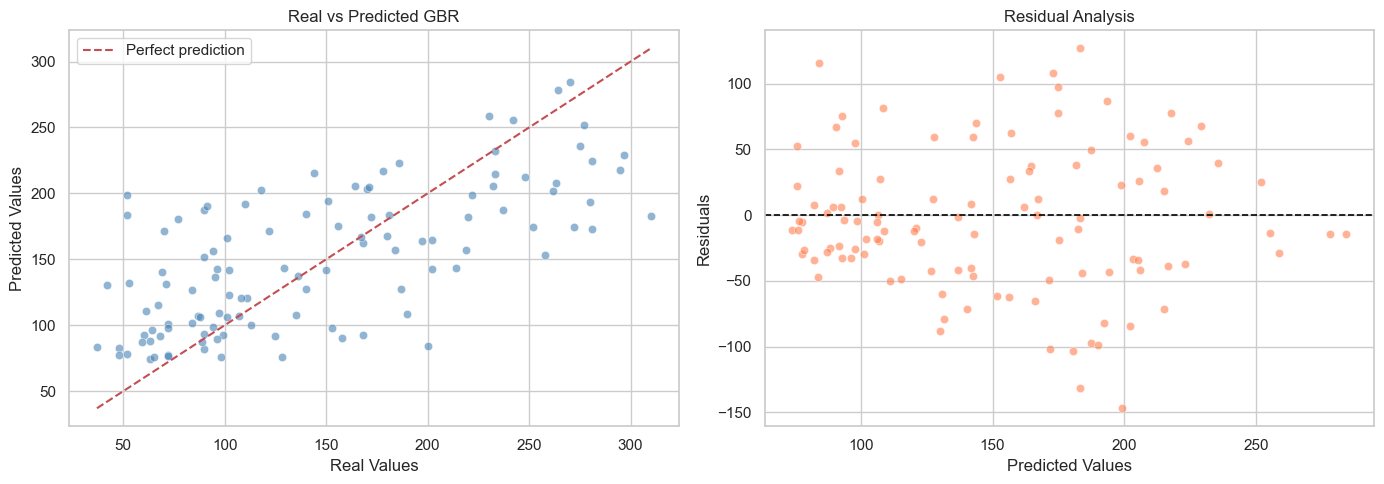

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter real vs predicted
axes[0].scatter(y_test, y_pred, alpha=0.6, color='steelblue', edgecolors='white', linewidths=0.5)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Real Values')
axes[0].set_ylabel('Predicted Values')
axes[0].set_title('Real vs Predicted GBR')
axes[0].legend()

# Residui
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.6, color='coral', edgecolors='white', linewidths=0.5)
axes[1].axhline(0, color='black', linewidth=1.2, linestyle='--')
axes[1].set_xlabel('Predicted Values')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Analysis')

plt.tight_layout()
plt.show()


## 9. Feature Importance

We analyze which clinical variables carry the most weight in the model.  
This is useful for the medical team: understanding which indicators are most predictive allows them to focus monitoring efforts on the right measurements.

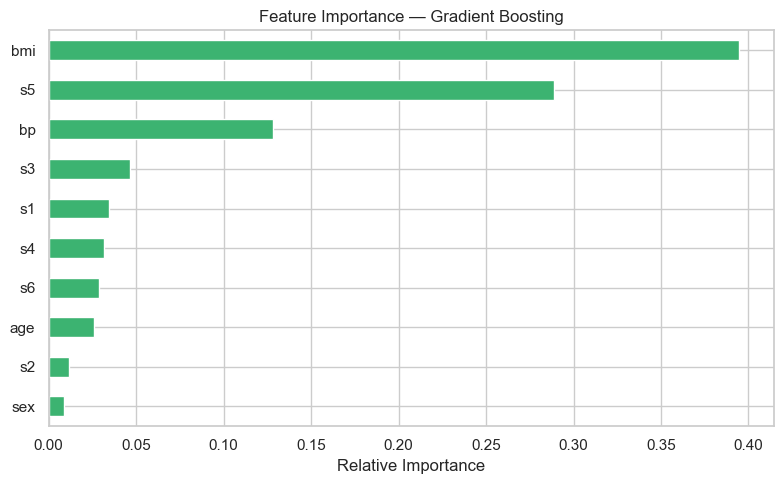


Top 3 most important features
bmi    0.394842
s5     0.288602
bp     0.128392
dtype: float64


In [12]:
feat_imp = pd.Series(
    best_model.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
feat_imp.plot(kind='barh', color='mediumseagreen', edgecolor='white')
plt.title('Feature Importance — Gradient Boosting')
plt.xlabel('Relative Importance')
plt.tight_layout()
plt.show()

print("\nTop 3 most important features")
print(feat_imp.sort_values(ascending=False).head(3))


## 10. Final Cross-Validation

For a more robust performance estimate, we run a **5-fold cross-validation** on the optimal model using the entire dataset.  
This provides a more reliable confidence interval compared to a single train/test split.

In [13]:
cv_scores = cross_val_score(
    best_model, X_train, y_train,
    cv=5,
    scoring='r2'
)

print("R² per each fold:", cv_scores.round(4))
print(f"\nMedian R² :  {cv_scores.mean():.4f}")
print(f"Std deviation: {cv_scores.std():.4f}")


R² per each fold: [0.5036 0.2553 0.4249 0.5837 0.3231]

Median R² :  0.4181
Std deviation: 0.1186


## 10. Conclusions

- On this dataset, Ridge Regression (R² = 0.49) achieves slightly better generalization than GBR (R² = 0.47), likely due to the small sample size and the predominantly linear structure of the data. GBR remains a valid choice when non-linear patterns are present or when the dataset is larger."
- The most important features are **bmi**, **s5** (log-triglycerides) and **bp** (blood pressure), consistently with the medical literature on diabetes progression.
- Cross-validation confirmed the stability of the model across different data splits.
- **For the medical team:** patients with high BMI and elevated s5 values should receive priority monitoring, as these indicators are the strongest predictors of disease progression.

### Possible Future Improvements
- Test models such as **XGBoost** or **LightGBM** for potential performance gains.
- Explore feature engineering (e.g. interactions between BMI and blood pressure).
- With real-world non-standardized data, add a robust preprocessing pipeline.
